In [ ]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# grab all daily files and combine
files = glob.glob("POWER_*.csv")

dfs = [pd.read_csv(f) for f in files]
wide = pd.concat(dfs, ignore_index=True)

In [ ]:
# pivot wide -> long
id_cols = ["entity_id", "type", "unit"]
long = wide.melt(id_vars=id_cols, var_name="timestamp", value_name="power_w")
long = long.dropna(subset=["power_w"])

long["power_w"] = pd.to_numeric(long["power_w"])
long["timestamp"] = pd.to_datetime(long["timestamp"], format="mixed", utc=True)

# clean duplicates
long = long.drop_duplicates(subset=["entity_id", "timestamp"])

# sort by time 
long = long.sort_values(by=['timestamp'])

# categorise as weekday / weekend
long['day_type'] = long['timestamp'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
long = long[['timestamp', 'power_w', 'day_type']]


In [5]:
long.head(10)

,timestamp,power_w,day_type
758374,2026-07-11 20:12:22.524808+00:00,2.750,Weekend
758396,2026-07-11 20:12:52.717167+00:00,2.667,Weekend
758418,2026-07-11 20:13:22.538735+00:00,2.878,Weekend
758440,2026-07-11 20:13:52.523467+00:00,2.975,Weekend
758462,2026-07-11 20:14:22.651051+00:00,2.928,Weekend
758484,2026-07-11 20:14:52.526337+00:00,2.987,Weekend
758506,2026-07-11 20:15:22.533235+00:00,2.969,Weekend
758528,2026-07-11 20:15:52.515931+00:00,3.257,Weekend
758550,2026-07-11 20:16:22.516593+00:00,2.889,Weekend
758572,2026-07-11 20:16:52.653037+00:00,3.003,Weekend


In [6]:
long.describe()

,power_w
count,58378.000000
mean,76.352406
std,308.626565
min,1.959000
25%,2.851000
50%,2.932000
75%,3.032000
max,2276.189000


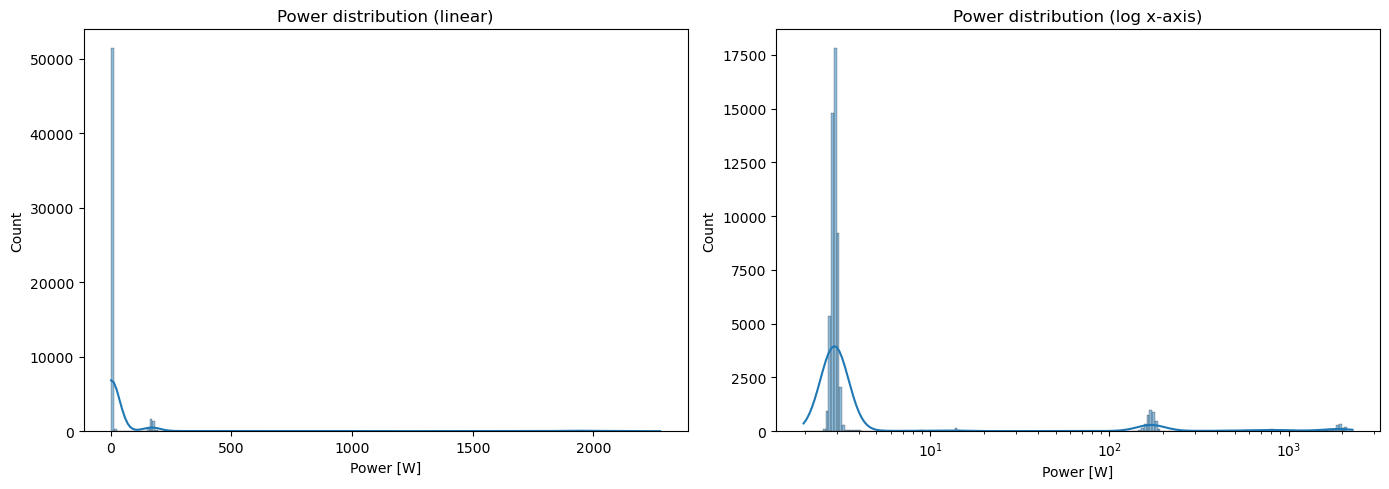

In [8]:
power = long['power_w'].dropna()
power_nonzero = power[power > 0] 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
# why KDE cuve? 
sns.histplot(power_nonzero, bins=200, kde=True, ax=axes[0])
axes[0].set_title('Power distribution (linear)')
axes[0].set_xlabel('Power [W]')

# Log scale — often reveals structure hidden by the low-power spike dominating linear scale
sns.histplot(power_nonzero, bins=200, kde=True, ax=axes[1], log_scale=True)
axes[1].set_title('Power distribution (log x-axis)')
axes[1].set_xlabel('Power [W]')

plt.tight_layout()
plt.show()

# filter out baseline energy usage from human usage - then fit 
# Was there a power threshold for more than 40 seconds - Yes/No; sliding window 

In [9]:
from sklearn.mixture import GaussianMixture

# Gaussian Mixtude model - why? 
# assume data comes from 3 underlying Gaussian ("mode") clusters 
train_data = long.loc[long['power_w'] > 0, 'power_w'].values.reshape(-1, 1)
gmm3 = GaussianMixture(n_components=3, random_state=42, n_init=10) # run EM alogirhtm 10 times, different initialisations, keeps best fit
gmm3.fit(train_data)

print("Means:", sorted(gmm3.means_.flatten()))

Means: [2.9126337025332742, 250.5481011916588, 1839.502030671705]


1. Establish the event threshold

In [20]:
# if power > 260 W for more than 25 seconds = Human use 

spike_threshold_w  = 260 
min_duration_sec = 25

2. Detect and log every human event

In [21]:
long = long.sort_values('timestamp').reset_index(drop=True)
long['diff_sec'] = long['timestamp'].diff().dt.total_seconds()

# flag each instance as above/below power threshold 
above = long['power_w'] > spike_threshold_w

# continuous run of above/below samples given a unique id 
# (id only changes when above/below state flips, so one run = one id)
long['block_id'] = (above != above.shift()).cumsum()

# for every continuous run that's above threshold, how long does it last? 
event_blocks = (
    long[above]
    .groupby('block_id')['timestamp']
    .agg(start='min', end='max')
)
event_blocks['duration_sec'] = (event_blocks['end'] - event_blocks['start']).dt.total_seconds()

# only keep runs that stay above threshold for more than min_duration_sec
qualifying_blocks = event_blocks[event_blocks['duration_sec'] > min_duration_sec]

# mark event_start only at the first sample of each qualifying (real, human-length)
long['event_start'] = long['block_id'].map(qualifying_blocks['start'])
long.loc[long['timestamp'] != long['event_start'], 'event_start'] = pd.NaT


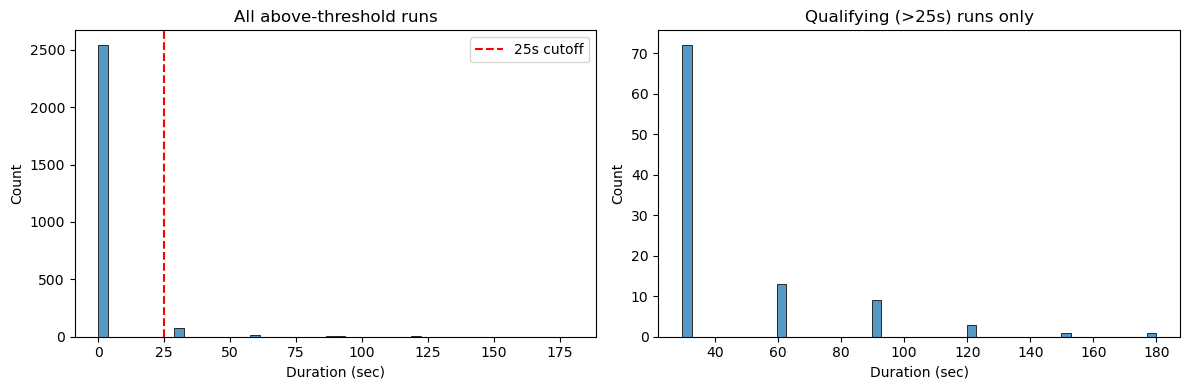

In [ ]:
# spread of runs?

event_blocks['duration_sec'].describe()
qualifying_blocks['duration_sec'].describe() # real human-use events

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(event_blocks['duration_sec'], bins=50, ax=axes[0])
axes[0].axvline(min_duration_sec, color='red', linestyle='--', label=f'{min_duration_sec}s cutoff')
axes[0].set_title('All above-threshold runs')
axes[0].set_xlabel('Duration (sec)')
axes[0].legend()

sns.histplot(qualifying_blocks['duration_sec'], bins=50, ax=axes[1])
axes[1].set_title('Qualifying (>25s) runs only')
axes[1].set_xlabel('Duration (sec)')

plt.tight_layout()
plt.show()

In [ ]:
standby_w = sorted(gmm3.means_.flatten())[0]          # idle mode from GMM

long['excess_w'] = (long['power_w'] - standby_w).clip(lower=0)   # power above baseline
long['excess_wh'] = long['excess_w'] * long['diff_sec'] / 3600   # power × time = energy (Wh)

qualifying_mask = long['block_id'].isin(qualifying_blocks.index)
event_energy = long[qualifying_mask].groupby('block_id')['excess_wh'].sum()
qualifying_blocks = qualifying_blocks.join(event_energy.rename('human_use_wh'))

total_wh = (long['power_w'] * long['diff_sec'] / 3600).sum()
human_use_wh = long.loc[qualifying_mask, 'excess_wh'].sum()
baseline_wh = total_wh - human_use_wh

In [11]:
events = long.dropna(subset=['event_start']).copy()
events['event_start'] = pd.to_datetime(events['event_start'])

# Extract hour-of-day and date separately
events['hour'] = events['event_start'].dt.hour
events['date'] = events['event_start'].dt.date

# Count events per hour per day
counts_per_day = (
    events.groupby(['date', 'hour'])
    .size()
    .rename('event_count')
    .reset_index()
)

# Average across days for each hour-of-day
avg_per_hour = (
    counts_per_day.groupby('hour')['event_count']
    .mean()
    .reindex(range(24), fill_value=0)  # ensures all 24 hours show, even if 0 events
    .rename('avg_events_per_hour')
    .reset_index()
)

In [12]:
# probability of at least one event occurring in a given minute
avg_per_hour['lambda_per_min'] = avg_per_hour['avg_events_per_hour'] / 60
avg_per_hour['p_trigger'] = 1 - np.exp(-avg_per_hour['lambda_per_min'])

# lookup array indexed by hour (0-23)
probability_lookup = avg_per_hour.set_index('hour')['p_trigger'].reindex(range(24), fill_value=0).values